In [1]:
import os
import cv2
import torch
import hashlib
import random
import numpy as np
import pandas as pd

from tqdm import tqdm
from glob import glob

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms


from pytorchvideo.models.hub import x3d_m, i3d_r50

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [2]:
DATASET_PATH = "D:/NU/CT/Project 3/Shoplifting_Detection/Data"

classes = os.listdir(DATASET_PATH)
print("Classes:", classes)

Classes: ['non shop lifters', 'shop lifters']


In [3]:
data = []

for label in classes:

    class_path = os.path.join(DATASET_PATH, label)

    for video_path in glob(class_path + "/*.mp4"):

        cap = cv2.VideoCapture(video_path)

        frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

        data.append({
            "path": video_path,
            "label": label,
            "frames": frames,
            "width": width,
            "height": height
        })

        cap.release()

df = pd.DataFrame(data)

label_map = {c: i for i, c in enumerate(classes)}

df["label_id"] = df["label"].map(label_map)

print(label_map)
df.head()

{'non shop lifters': 0, 'shop lifters': 1}


,path,label,frames,width,height,label_id
0,D:/NU/CT/Project 3/Shoplifting_Detection/Data\...,non shop lifters,450,704,576,0
1,D:/NU/CT/Project 3/Shoplifting_Detection/Data\...,non shop lifters,450,704,576,0
2,D:/NU/CT/Project 3/Shoplifting_Detection/Data\...,non shop lifters,450,704,576,0
3,D:/NU/CT/Project 3/Shoplifting_Detection/Data\...,non shop lifters,475,704,576,0
4,D:/NU/CT/Project 3/Shoplifting_Detection/Data\...,non shop lifters,400,704,576,0


In [4]:
df.groupby("label")["frames"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
non shop lifters,531.0,347.783427,134.202129,75.0,275.0,348.0,400.0,1850.0
shop lifters,324.0,304.601852,83.470572,100.0,248.0,300.0,372.0,570.0


In [5]:
print("Dataset size:", len(df))

print("\nClass Distribution:")
print(df['label'].value_counts())

print("\nFrame Statistics:")
print(df['frames'].describe())

Dataset size: 855

Class Distribution:
label
non shop lifters    531
shop lifters        324
Name: count, dtype: int64

Frame Statistics:
count     855.000000
mean      331.419883
std       119.381055
min        75.000000
25%       250.000000
50%       325.000000
75%       396.000000
max      1850.000000
Name: frames, dtype: float64


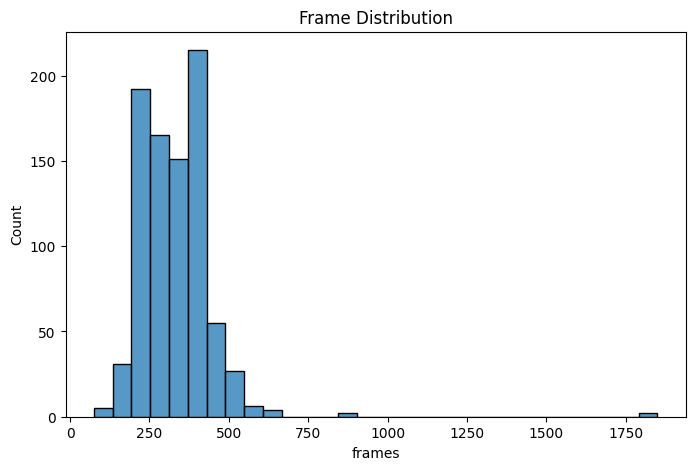

In [6]:
plt.figure(figsize=(8,5))
sns.histplot(df["frames"], bins=30)
plt.title("Frame Distribution")
plt.show()

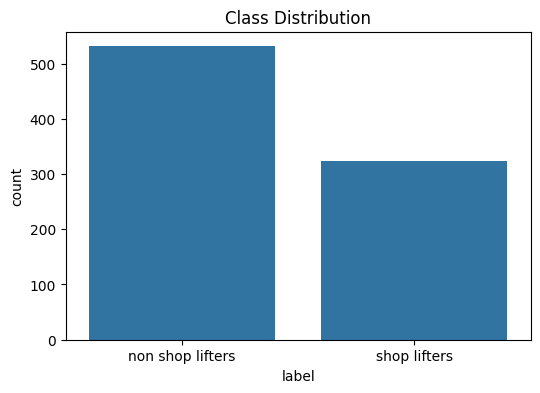

In [7]:
plt.figure(figsize=(6,4))
sns.countplot(x=df["label"])
plt.title("Class Distribution")
plt.show()

In [8]:
def get_md5(file_path):

    hash_md5 = hashlib.md5()

    with open(file_path, "rb") as f:

        for chunk in iter(lambda: f.read(4096), b""):
            hash_md5.update(chunk)

    return hash_md5.hexdigest()


hashes = {}
duplicates = []

for path in tqdm(df["path"]):

    file_hash = get_md5(path)

    if file_hash in hashes:
        duplicates.append(path)
    else:
        hashes[file_hash] = path

print("Duplicates:", len(duplicates))

100%|██████████| 855/855 [00:08<00:00, 96.09it/s] 

Duplicates: 218


In [9]:
df = df[~df["path"].isin(duplicates)]

df = df.reset_index(drop=True)

print("Dataset after removing duplicates:", len(df))

Dataset after removing duplicates: 637


In [10]:
TARGET_FRAMES = 16
IMG_SIZE = 224

def load_video(path):

    cap = cv2.VideoCapture(path)

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    frame_indices = np.linspace(
        0, total_frames-1, TARGET_FRAMES
    ).astype(int)

    frames = []

    for idx in frame_indices:

        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)

        ret, frame = cap.read()

        if not ret:
            break

        frame = cv2.resize(frame, (IMG_SIZE, IMG_SIZE))
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        frames.append(frame)

    cap.release()

    frames = np.array(frames) / 255.0

    return frames

In [11]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.3,
    stratify=df["label_id"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["label_id"]
)

In [12]:
import random
import torchvision.transforms as transforms

def video_transform(video, train=True):

    frames = []

    flip = random.random() > 0.5
    angle = random.uniform(-10, 10)
    brightness = random.uniform(0.8, 1.2)

    for frame in video:

        frame = transforms.ToPILImage()(frame)

        if train:
            if flip:
                frame = transforms.functional.hflip(frame)
            frame = transforms.functional.rotate(frame, angle)
            frame = transforms.functional.adjust_brightness(frame, brightness)

        frame = transforms.ToTensor()(frame)
        frame = transforms.Normalize([0.45]*3, [0.225]*3)(frame)

        frames.append(frame)

    return torch.stack(frames)   # (T, C, H, W)

In [13]:
labels = df["label_id"].values

class_counts = np.bincount(labels)

class_weights = 1. / class_counts
class_weights = class_weights / class_weights.sum()

class_weights = torch.tensor(class_weights, dtype=torch.float32)

print("Class counts:", class_counts)
print("Class weights:", class_weights)

Class counts: [313 324]
Class weights: tensor([0.5086, 0.4914])


In [14]:
from torch.utils.data import Dataset

class VideoDataset(Dataset):

    def __init__(self, df, train=True):
        self.df = df
        self.train = train

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        video = load_video(row["path"])
        video = video_transform(video, train=self.train)

        # Convert to (C, T, H, W) for X3D/I3D
        video = video.permute(1, 0, 2, 3)

        label = torch.tensor(row["label_id"], dtype=torch.long)

        return video, label

In [16]:
train_dataset = VideoDataset(train_df, train=True)
val_dataset   = VideoDataset(val_df, train=False)
test_dataset  = VideoDataset(test_df, train=False)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=4, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=4, shuffle=False)

In [17]:
from pytorchvideo.models.hub import x3d_m, i3d_r50

model_x3d = x3d_m(pretrained=True)
model_i3d = i3d_r50(pretrained=True)

# Replace heads
model_x3d.blocks[-1].proj = torch.nn.Linear(2048, len(classes))
model_i3d.blocks[-1].proj = torch.nn.Linear(2048, len(classes))

In [18]:
from tqdm import tqdm
from sklearn.metrics import precision_score, recall_score, f1_score

def train_model(model, train_loader, val_loader, class_weights, epochs=10):

    model = model.to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=3e-5,
        weight_decay=1e-2
    )

    criterion = nn.CrossEntropyLoss(
        weight=class_weights.to(device)
    )

    history = {
        "train_loss": [],
        "val_loss": [],
        "precision": [],
        "recall": [],
        "f1": []
    }

    for epoch in range(epochs):

        # ================= TRAIN =================
        model.train()

        running_loss = 0

        progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")

        for videos, labels in progress_bar:

            videos = videos.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(videos)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

            progress_bar.set_postfix(
                loss = running_loss/(progress_bar.n+1)
            )

        train_loss = running_loss / len(train_loader)

        history["train_loss"].append(train_loss)

        # ================= VALIDATION =================
        model.eval()

        val_running_loss = 0

        preds = []
        targets = []

        with torch.no_grad():

            for videos, labels in val_loader:

                videos = videos.to(device)
                labels = labels.to(device)

                outputs = model(videos)

                loss = criterion(outputs, labels)

                val_running_loss += loss.item()

                predicted = torch.argmax(outputs, dim=1)

                preds.extend(predicted.cpu().numpy())
                targets.extend(labels.cpu().numpy())

        val_loss = val_running_loss / len(val_loader)

        history["val_loss"].append(val_loss)

        precision = precision_score(targets, preds)
        recall = recall_score(targets, preds)
        f1 = f1_score(targets, preds)

        history["precision"].append(precision)
        history["recall"].append(recall)
        history["f1"].append(f1)

        print("\n------------------------------")
        print(f"Epoch {epoch+1}/{epochs}")
        print(f"Train Loss : {train_loss:.4f}")
        print(f"Val Loss   : {val_loss:.4f}")
        print(f"Precision  : {precision:.4f}")
        print(f"Recall     : {recall:.4f}")
        print(f"F1 Score   : {f1:.4f}")
        print("------------------------------")

    return model, history

# X3D Model

In [97]:
model_x3d, history_x3d = train_model(
    model,
    train_loader,
    val_loader,
    class_weights,
    epochs=5
)

Epoch 1/5: 100%|██████████| 112/112 [45:27<00:00, 24.35s/it, loss=0.135]



------------------------------
Epoch 1/5
Train Loss : 0.1352
Val Loss   : 0.0914
Precision  : 0.9074
Recall     : 1.0000
F1 Score   : 0.9515
------------------------------


Epoch 2/5: 100%|██████████| 112/112 [46:47<00:00, 25.07s/it, loss=0.0943]



------------------------------
Epoch 2/5
Train Loss : 0.0943
Val Loss   : 0.0667
Precision  : 0.9796
Recall     : 0.9796
F1 Score   : 0.9796
------------------------------


Epoch 3/5: 100%|██████████| 112/112 [40:30<00:00, 21.70s/it, loss=0.0713]



------------------------------
Epoch 3/5
Train Loss : 0.0713
Val Loss   : 0.0657
Precision  : 0.9608
Recall     : 1.0000
F1 Score   : 0.9800
------------------------------


Epoch 4/5: 100%|██████████| 112/112 [41:02<00:00, 21.98s/it, loss=0.0544]



------------------------------
Epoch 4/5
Train Loss : 0.0544
Val Loss   : 0.0376
Precision  : 0.9800
Recall     : 1.0000
F1 Score   : 0.9899
------------------------------


Epoch 5/5: 100%|██████████| 112/112 [40:52<00:00, 21.90s/it, loss=0.051] 



------------------------------
Epoch 5/5
Train Loss : 0.0510
Val Loss   : 0.0392
Precision  : 1.0000
Recall     : 1.0000
F1 Score   : 1.0000
------------------------------


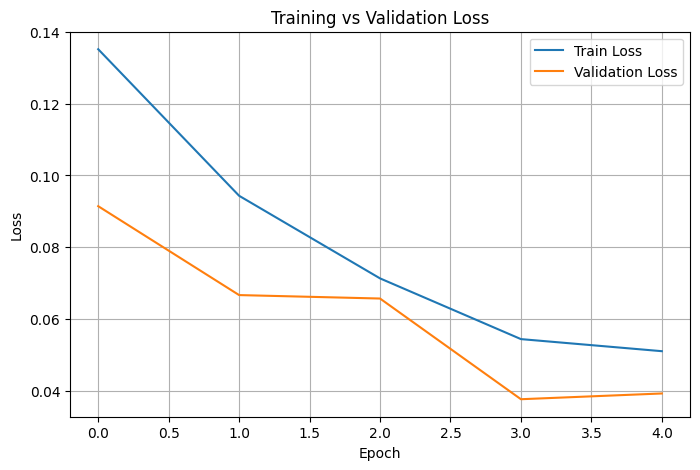

In [98]:
import matplotlib.pyplot as plt

def plot_losses(history):

    plt.figure(figsize=(8,5))

    plt.plot(history["train_loss"], label="Train Loss")
    plt.plot(history["val_loss"], label="Validation Loss")

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training vs Validation Loss")
    plt.legend()

    plt.grid()
    plt.show()
plot_losses(history_x3d)

In [99]:
from sklearn.metrics import precision_score, recall_score, f1_score

def test_model(model, test_loader):

    model.eval()

    preds = []
    targets = []

    with torch.no_grad():

        for videos, labels in test_loader:

            videos = videos.to(device)
            labels = labels.to(device)

            outputs = model(videos)

            # support TimeSformer later
            if isinstance(outputs, dict):
                outputs = outputs["logits"]

            predicted = torch.argmax(outputs, dim=1)

            preds.extend(predicted.cpu().numpy())
            targets.extend(labels.cpu().numpy())

    precision = precision_score(targets, preds, zero_division=0)
    recall = recall_score(targets, preds, zero_division=0)
    f1 = f1_score(targets, preds, zero_division=0)

    print("\n===== TEST RESULTS =====")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")

    return preds, targets

In [100]:
preds, targets = test_model(model, test_loader)


===== TEST RESULTS =====
Precision : 1.0000
Recall    : 0.9592
F1 Score  : 0.9792


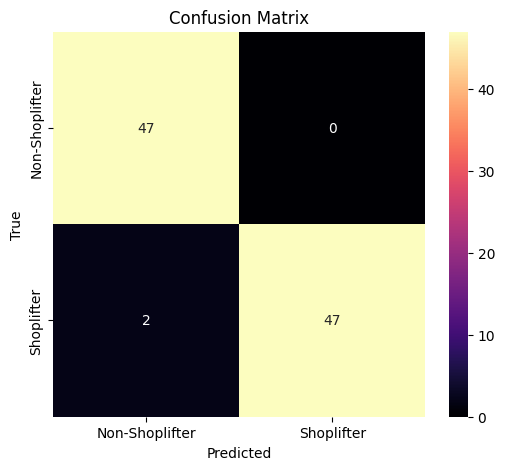

In [101]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

def plot_confusion_matrix(preds, targets):

    cm = confusion_matrix(targets, preds)

    class_names = ["Non-Shoplifter", "Shoplifter"]

    plt.figure(figsize=(6,5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="magma",
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")

    plt.show()
plot_confusion_matrix(preds, targets)

# I3D Model

In [21]:
model_i3d, history_i3d = train_model(
    model_i3d,
    train_loader,
    val_loader,
    class_weights,
    epochs=5
)

Epoch 1/5: 100%|██████████| 112/112 [49:48<00:00, 26.69s/it, loss=0.609]



------------------------------
Epoch 1/5
Train Loss : 0.6094
Val Loss   : 0.4235
Precision  : 0.8478
Recall     : 0.7959
F1 Score   : 0.8211
------------------------------


Epoch 2/5: 100%|██████████| 112/112 [46:59<00:00, 25.17s/it, loss=0.41] 



------------------------------
Epoch 2/5
Train Loss : 0.4097
Val Loss   : 0.2614
Precision  : 0.9111
Recall     : 0.8367
F1 Score   : 0.8723
------------------------------


Epoch 3/5: 100%|██████████| 112/112 [48:47<00:00, 26.13s/it, loss=0.258]



------------------------------
Epoch 3/5
Train Loss : 0.2579
Val Loss   : 0.1936
Precision  : 0.8909
Recall     : 1.0000
F1 Score   : 0.9423
------------------------------


Epoch 4/5: 100%|██████████| 112/112 [47:30<00:00, 25.45s/it, loss=0.183]



------------------------------
Epoch 4/5
Train Loss : 0.1834
Val Loss   : 0.0631
Precision  : 0.9608
Recall     : 1.0000
F1 Score   : 0.9800
------------------------------


Epoch 5/5: 100%|██████████| 112/112 [51:54<00:00, 27.81s/it, loss=0.187]



------------------------------
Epoch 5/5
Train Loss : 0.1869
Val Loss   : 0.0548
Precision  : 0.9600
Recall     : 0.9796
F1 Score   : 0.9697
------------------------------


In [22]:
from sklearn.metrics import precision_score, recall_score, f1_score

def test_model(model, test_loader):

    model.eval()

    preds = []
    targets = []

    with torch.no_grad():

        for videos, labels in test_loader:

            videos = videos.to(device)
            labels = labels.to(device)

            outputs = model(videos)

            # support TimeSformer later
            if isinstance(outputs, dict):
                outputs = outputs["logits"]

            predicted = torch.argmax(outputs, dim=1)

            preds.extend(predicted.cpu().numpy())
            targets.extend(labels.cpu().numpy())

    precision = precision_score(targets, preds, zero_division=0)
    recall = recall_score(targets, preds, zero_division=0)
    f1 = f1_score(targets, preds, zero_division=0)

    print("\n===== TEST RESULTS =====")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")

    return preds, targets

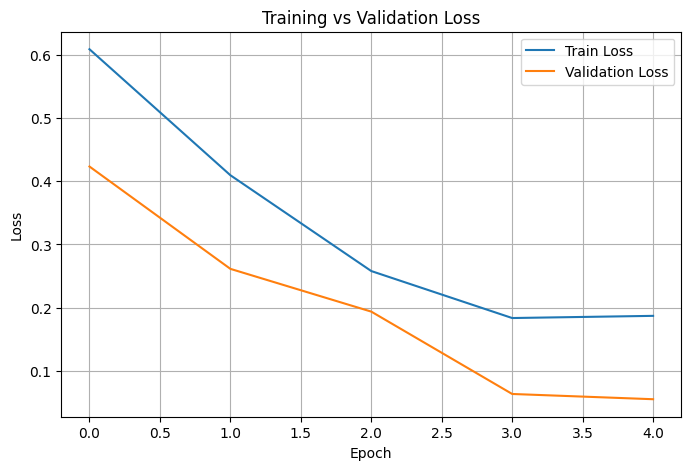

In [23]:
import matplotlib.pyplot as plt

def plot_losses(history):

    plt.figure(figsize=(8,5))

    plt.plot(history["train_loss"], label="Train Loss")
    plt.plot(history["val_loss"], label="Validation Loss")

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training vs Validation Loss")
    plt.legend()

    plt.grid()
    plt.show()
plot_losses(history_i3d)

In [25]:
preds, targets = test_model(model_i3d, test_loader)


===== TEST RESULTS =====
Precision : 1.0000
Recall    : 1.0000
F1 Score  : 1.0000


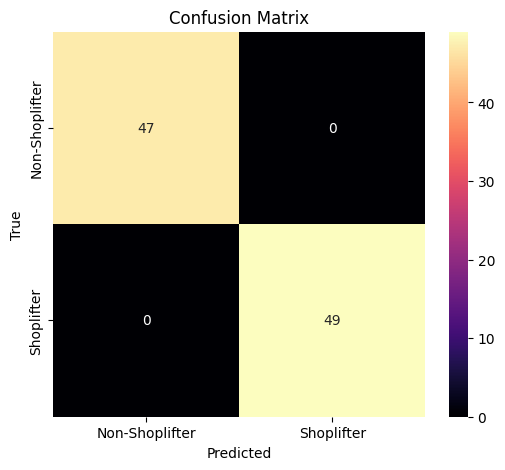

In [26]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

def plot_confusion_matrix(preds, targets):

    cm = confusion_matrix(targets, preds)

    class_names = ["Non-Shoplifter", "Shoplifter"]

    plt.figure(figsize=(6,5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="magma",
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")

    plt.show()
plot_confusion_matrix(preds, targets)

In [27]:
torch.save(model_x3d.state_dict(), "x3d_model.pth")
torch.save(model_i3d.state_dict(), "i3d_model.pth")